

# Data Loading and preprocessing

# Handling Missing Values and Data Cleaning

# Descriptive Statistics and Summay

# Visualization (Univariate, bivariate, multivariate)

# Insights on Churn Behaviour



In [1]:
# load important librabires for EDA project

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# load the data into df variable

In [4]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# as we see the data is huge. So all columns not showing
# So lets check the total columns name

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
# lets check the shape of data

In [9]:
df.shape

(7043, 21)

In [10]:
# The data set contains 7043 rows indicate customers with 21 features
# Each row represent a unique customer with various attributes
# related to demographic, services and billing
# The dataset size is sufficient for meaningful analysis and prediction
# with 21 features, we have a good mix of xategorical and numerical
# to explore customer behaviour and churn pattern.

In [11]:
# lets check data types of each feature

In [12]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [13]:
# most of the columns are categorical (object type)
# SeniorCitizen is stored as int64, but since its a binary variable
# 0 & 1 it can be treated as categorical
# Total charges is stored as an object, which seems incorrect
# Since it represent a numerical values
# It may contain missing values or be formatted incorrect
# We need to convert it to float for proper analysis

In [14]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [15]:
# check the conversion

In [16]:
df['TotalCharges'].dtype

dtype('float64')

In [17]:
# Check for missing values in each columns

In [18]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [19]:
# only one column TotalCharges has missing values
# 11 missing values
# Since Total Charges is numerical, these missing values were
# likely empty spaces in original dataset before conversion
# possible ways to handle missing values:-
# 1 - fill them with median or mean of TotalCharges
# 2 - fill them with zero, but total charges not be zero
# 3 - Drop these 11 rows, but if we do 11 customers also drop for 7043. We myloss data
# So better to fill the missing value
# fill them with median, beacuse median is good if we may contain outlier

In [20]:
df['TotalCharges'].median()

1397.475

In [21]:
df['TotalCharges'].mean()

np.float64(2283.3004408418656)

In [22]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipython-input-2840544469.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [23]:
# so lets check the missing value again

In [24]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [25]:
# Lets check for the duplicate records

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [28]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [29]:
categorical_columns= ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'Churn']

In [30]:
for i in categorical_columns:
  print(f"Unique value in {i} is :- ")
  print(df[i].unique(), "\n")
  print("---------------------------")

Unique value in gender is :- 
['Female' 'Male'] 

---------------------------
Unique value in SeniorCitizen is :- 
[0 1] 

---------------------------
Unique value in Partner is :- 
['Yes' 'No'] 

---------------------------
Unique value in Dependents is :- 
['No' 'Yes'] 

---------------------------
Unique value in PhoneService is :- 
['No' 'Yes'] 

---------------------------
Unique value in MultipleLines is :- 
['No phone service' 'No' 'Yes'] 

---------------------------
Unique value in InternetService is :- 
['DSL' 'Fiber optic' 'No'] 

---------------------------
Unique value in OnlineSecurity is :- 
['No' 'Yes' 'No internet service'] 

---------------------------
Unique value in OnlineBackup is :- 
['Yes' 'No' 'No internet service'] 

---------------------------
Unique value in DeviceProtection is :- 
['No' 'Yes' 'No internet service'] 

---------------------------
Unique value in TechSupport is :- 
['No' 'Yes' 'No internet service'] 

---------------------------
Unique value in

In [31]:
# lets check for the distribution of numerical feature
# also check the outliers

Text(0.5, 1.0, 'Monthly Charges Boxplot')

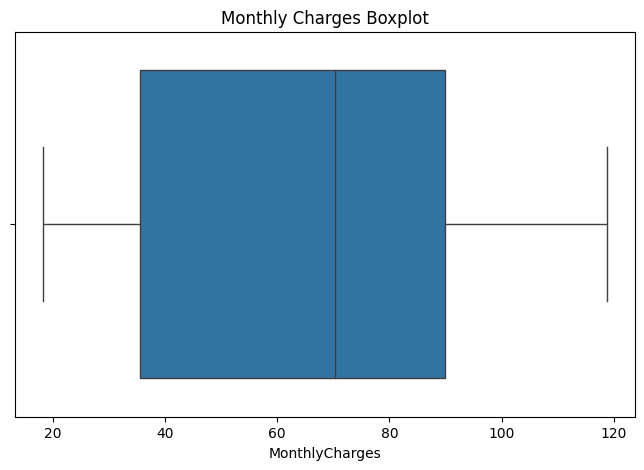

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(data = df, x= 'MonthlyCharges')
plt.title("Monthly Charges Boxplot")

Text(0.5, 1.0, 'Total Charges Boxplot')

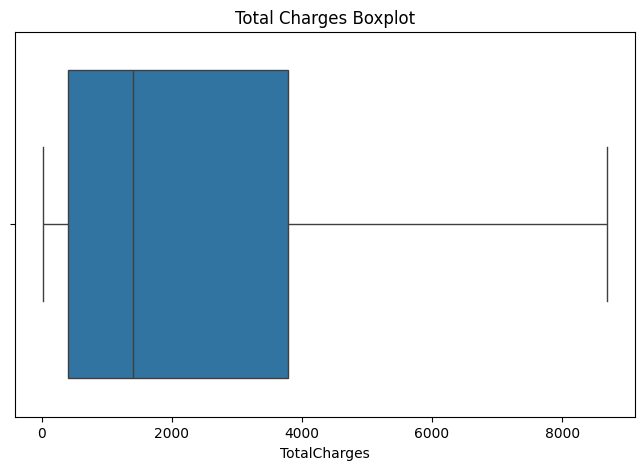

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(data = df, x= 'TotalCharges')
plt.title("Total Charges Boxplot")

In [35]:
# Since there are no outlier in the Monthly Charges and Total Charges
# This is the clean data distribution
# No extreme values are distorting the distribution
# This mean data is already well behaved for statistical analysis and modeling
# No need for transformation or removal

In [36]:
df[["TotalCharges", "MonthlyCharges", "tenure"]].describe()

,TotalCharges,MonthlyCharges,tenure
count,7043.000000,7043.000000,7043.000000
mean,2281.916928,64.761692,32.371149
std,2265.270398,30.090047,24.559481
min,18.800000,18.250000,0.000000
25%,402.225000,35.500000,9.000000
50%,1397.475000,70.350000,29.000000
75%,3786.600000,89.850000,55.000000
max,8684.800000,118.750000,72.000000


In [37]:
# The average of TotalCharge per customer is 2281.91
# and the median that is middle value is 1397.48, which is significantly
# indicate that median is lower than mean i.e., right skew distribution
# The MonthlyCharge also little bit left skew
# The median tenure is 29 month. maximum customer is for long term

In [38]:
# To understand the distribution of the tenure among customer

In [39]:
# Histogram / kde plot

Text(0.5, 1.0, 'Distribution of tenure among customer')

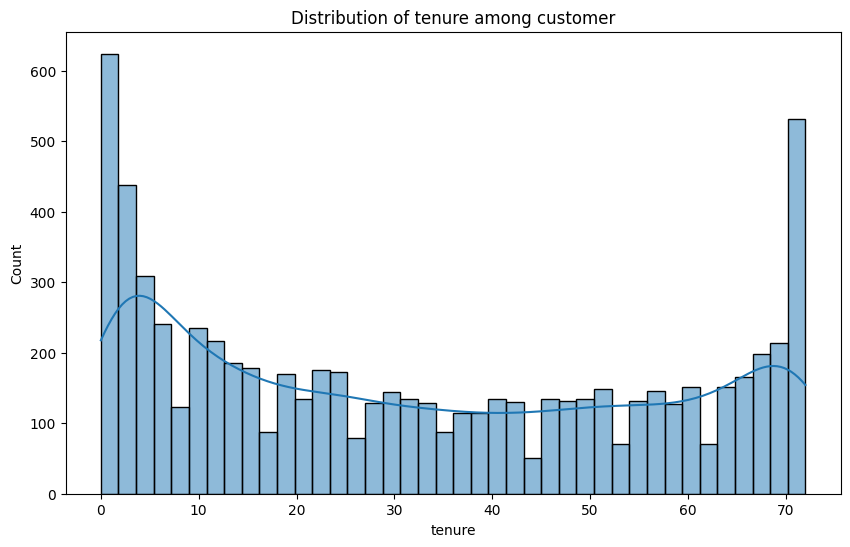

In [40]:
plt.figure(figsize= (10,6))
sns.histplot(data=df, x='tenure', kde=True, bins=40)
plt.title("Distribution of tenure among customer")

In [41]:
# the fact that the distribution looks uniform, suggest that customers are
# evenly distribution accross different tenure range
# so lets check for the MonthlyCharges and TotalCharges distribution

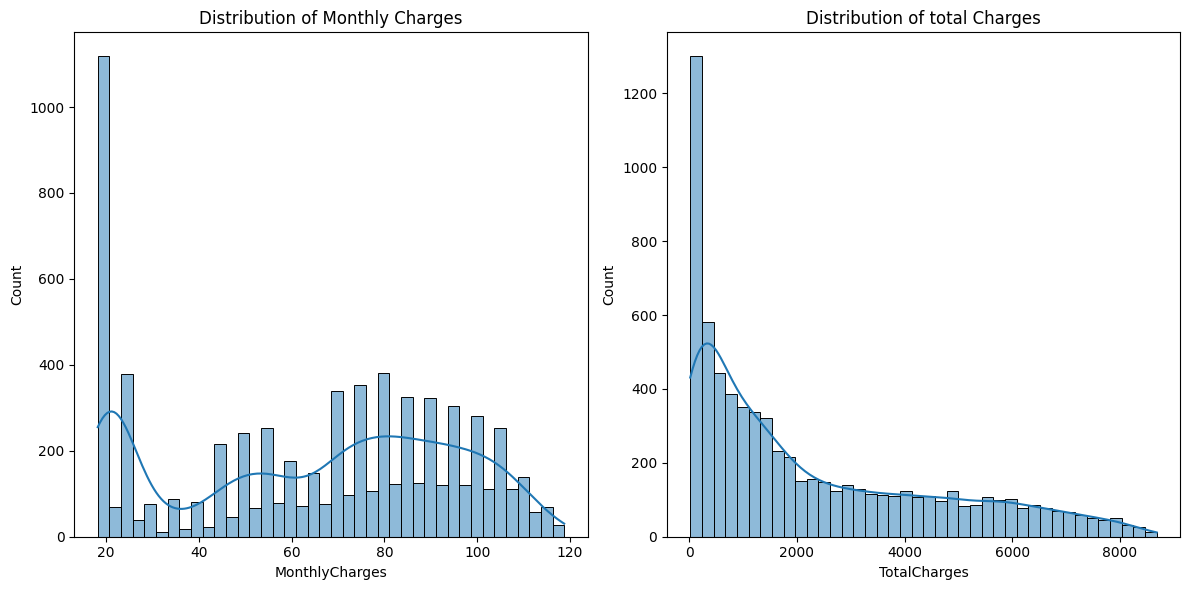

In [42]:
plt.figure(figsize= (12,6))

plt.subplot(1,2,1)
sns.histplot(data=df, x="MonthlyCharges", kde=True, bins=40)
plt.title("Distribution of Monthly Charges")

plt.subplot(1,2,2)
sns.histplot(data=df, x="TotalCharges", kde=True, bins=40)
plt.title("Distribution of total Charges")

plt.tight_layout()

In [43]:
# MontlyCharges- symmetric distribution spread accross 18 to 118
# TotalCharges- right skewed with many low charges customers

In [44]:
# lets check for the categorical columns

In [46]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [47]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


Text(0.5, 1.0, 'Customers count by Contract')

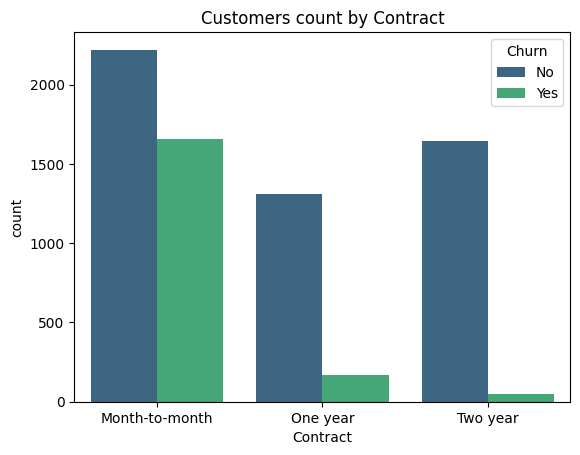

In [48]:
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title("Customers count by Contract")

In [50]:
df.groupby("Contract")["Churn"].value_counts().unstack()

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [52]:
df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack()*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [53]:
# Majority of customers approx 42% are on month-to-month which is potential churn
# One year and two year contract indicating higher stability
# business impication - customers on month-to-month contracts
# may need loyalty discount to commit a longer contract
# long-term customers should be rewarded with better benefit to maintain
# retention